# Reparameterization of Hierarchical Models in HSSM

*Authors: Maria Ma, Andrew Zhang*

## 1. Introduction

This tutorial walks you through the **centered** and **non-centered** parameterizations of a hierarchical model in HSSM — two mathematically equivalent forms that the sampler can treat very differently (one mixes cleanly, the other fills the trace with divergences and poor mixing).

We use one hierarchical HSSM model — drift rate `v` varying across subjects — and:

- fit it under both parameterizations,
- vary the data per subject (10 / 30 / 100 / 300 trials) to see which form wins,
- read simple diagnostics (R-hat, ESS, divergences, and a few plots).

**Key result:** few trials per subject favor the non-centered form; many trials favor the centered form. In HSSM you switch between them with one argument, `noncentered=True/False`.

## 2. Background

### 2.1 Centered parameterization

The standard formulation of a hierarchical model: each subject's drift `v_k` is drawn around a group mean.

- group mean `mu_v`, group spread `sigma_v`
- each subject: `v_k ~ Normal(mu_v, sigma_v)`

Here `sigma_v` acts as a *freedom parameter*: a large value lets subjects differ; a small value pulls every subject toward the group mean. Because the spread of the `v_k` is governed directly by `sigma_v`, the two are tightly coupled, which causes funnel degeneracy.

### 2.2 Non-centered parameterization

The same model, rewritten so that the group spread and the subject values are no longer directly coupled. Each subject is assigned a standardized offset, and `v_k` is reconstructed from it:

- offset: `z_k ~ Normal(0, 1)`
- each subject: `v_k = mu_v + sigma_v * z_k`

Because the offsets no longer depend on `sigma_v`, the geometry the sampler explores is well-behaved. 


### 2.3 The funnel degeneracy

The **funnel degeneracy** appears when two things coincide: **`sigma_v` is small** and **per-subject data is weak**.

With little data, the likelihood barely constrains a subject's `v_k`, so the prior takes over and `sigma_v` controls how freely the subjects move. If `sigma_v` is also small, the subjects are all pulled tight to the group mean. Geometrically, the joint density is wide at large `sigma_v` and pinches into a thin **neck** at small `sigma_v` — Neal's funnel. A step size that works well in the wide region is too aggressive in the narrow neck, so the sampler either moves inefficiently (low ESS) or loses track of the geometry altogether (divergences).

With abundant per-subject data the likelihood pins each `v_k` on its own, `sigma_v` no longer forces the subjects together, and the degeneracy fades.

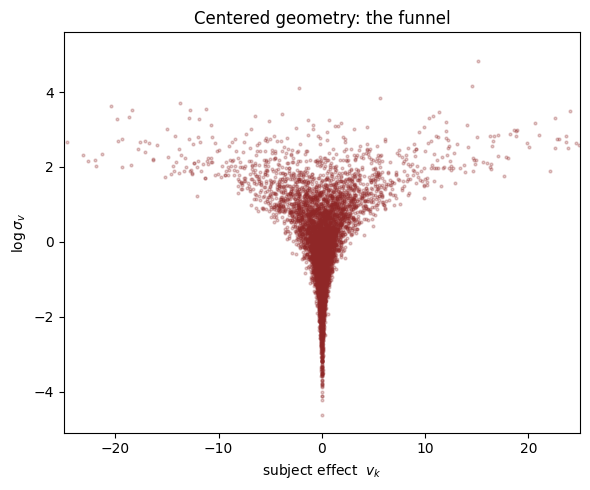

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)

n = 6000
log_sigma = rng.normal(0.0, 1.3, n)
theta = rng.normal(0.0, np.exp(log_sigma))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(theta, log_sigma, s=4, alpha=0.25, color="#8F2727")
ax.set_xlim(-25, 25)
ax.set_xlabel(r"subject effect  $v_k$")
ax.set_ylabel(r"$\log \sigma_v$")
ax.set_title("Centered geometry: the funnel")
plt.tight_layout()
plt.show()

### 2.4 Non-centering: undoing a funnel degeneracy, or creating one

Non-centering is not always a fix — its effect depends on whether a funnel degeneracy is already present.

When the centered form has a funnel (little data), non-centering resolves it: the offsets `z_k ~ Normal(0, 1)` no longer depend on `sigma_v`, so the neck disappears.

When there is no funnel to begin with (abundant data), non-centering can instead *create* one. The data pin `v_k` in place, so the offset `z_k = (v_k - mu_v) / sigma_v` scales like `1 / sigma_v` and grows without bound as `sigma_v` shrinks — the **inverse funnel degeneracy**.

The two forms therefore fail in opposite regimes: centered with *little* data, non-centered with *abundant* data.

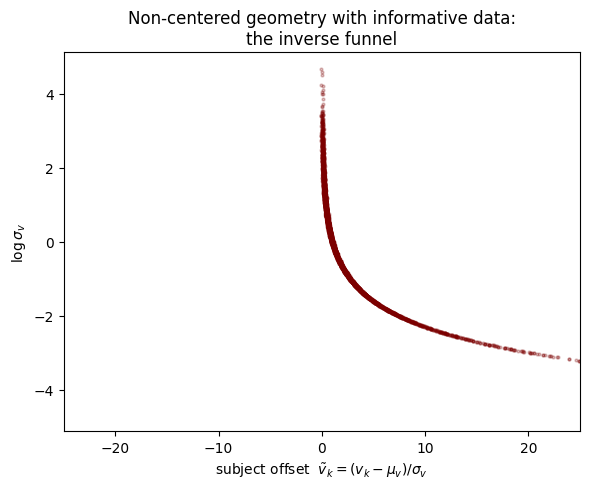

In [3]:
mu_v = 0.0
v_hat = 1.0  
log_sigma = rng.normal(0.0, 1.3, n)
sigma = np.exp(log_sigma)
offset = (v_hat - mu_v) / sigma + rng.normal(0, 0.05, n)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(offset, log_sigma, s=4, alpha=0.25, color="#7C0000")
ax.set_xlim(-25, 25)
ax.set_xlabel(r"subject offset  $\tilde v_k = (v_k-\mu_v)/\sigma_v$")
ax.set_ylabel(r"$\log \sigma_v$")
ax.set_title("Non-centered geometry with informative data:\nthe inverse funnel")
plt.tight_layout()
plt.show()

## 3. Simulation Setup

We build a hierarchical HSSM model where only the drift rate `v` varies across subjects (`a`, `z`, `t` are shared) and simulate four datasets — **10, 30, 100, 300** trials/subject. The extremes carry the contrast: sparse (10) favors non-centered (small `sigma_v` + weak likelihood = funnel); rich (300) favors centered (each `v_k` is pinned, so non-centering inverts the funnel). Intermediate conditions trace the crossover. We keep `sigma_v` small so the funnel can appear.

Each dataset is generated with the **do-operator** (`model.sample_do`), which fixes every parameter to a known value before drawing fresh `rt`/`response` — so we know exactly what produced each fit and can check recovery later.

In [4]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import hssm

seed = np.random.default_rng(2026)

sample_kwargs = dict(
    sampler="pymc",
    draws=1000,
    tune=1000,
    chains=2,
    target_accept=0.9,
    idata_kwargs={"log_likelihood": False},
)

You supplied a model 'racing_diffusion_3', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.
You supplied a model 'poisson_race', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


In [6]:
mu_v = 1.0
sigma_v = 0.3
a_true = 1.5
z_true = 0.5
t_true = 0.3

n_subjects = 20
trial_conditions = [10, 30, 100, 300]

v_subjects = seed.normal(mu_v, sigma_v, n_subjects)
v_offsets = (v_subjects - mu_v) / sigma_v

In [7]:
v_formula = "v ~ 1 + (1|participant_id)"

do_params = {
    "v_Intercept": mu_v,
    "v_1|participant_id_sigma": sigma_v,
    "v_1|participant_id_offset": v_offsets,
    "a": a_true,
    "z": z_true,
    "t": t_true,
}


def simulate_condition(n_trials):
    pid = np.repeat(np.arange(n_subjects), n_trials)
    covariates = pd.DataFrame({"participant_id": pid})

    gen_model = hssm.HSSM(
        data=covariates.assign(rt=1.0, response=1.0),
        model="ddm",
        include=[{"name": "v", "formula": v_formula}],
        noncentered=True,
        prior_settings=None,
    )
    synth_idata, _ = gen_model.sample_do(
        params=do_params,
        draws=1,
        var_names=["rt,response"],
        return_model=True,
    )

    synth_df = hssm.utils.predictive_idata_to_dataframe(
        synth_idata, predictive_group="prior_predictive"
    )
    out = covariates.copy()
    out["rt"] = synth_df["rt"].values
    out["response"] = synth_df["response"].values
    return out

In [8]:
for n_trials in trial_conditions:
    df = simulate_condition(n_trials)
    path = f"sim_repar_{n_trials}.csv"
    df.to_csv(path, index=False)

Model initialized successfully.


/Users/mayan/HSSM/src/hssm/hssm.py:504: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()
Sampling: [rt,response]


Model initialized successfully.


/Users/mayan/HSSM/src/hssm/hssm.py:504: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()
Sampling: [rt,response]


Model initialized successfully.


/Users/mayan/HSSM/src/hssm/hssm.py:504: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()
Sampling: [rt,response]
/Users/mayan/HSSM/src/hssm/hssm.py:504: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()


Model initialized successfully.


Sampling: [rt,response]


## 4. Fit Both Models Across All Conditions

For each dataset from §3, we fit the model twice — once centered, once non-centered — for eight fits total. The data and model are identical in both runs, so any difference in the diagnostics comes from the sampling geometry alone.

We record R-hat, bulk-ESS, and divergence count for `sigma_v` (the parameter most affected by the funnel). ESS is the loudest signal here; divergences are sporadic.

In [8]:
parameterizations = [("centered", False), ("non-centered", True)]
sigma_v_var = "v_1|participant_id_sigma"

idata_store = {}
records = []

for n_trials in trial_conditions:
    data = pd.read_csv(f"sim_repar_{n_trials}.csv")
    for label, nc in parameterizations:
        model = hssm.HSSM(
            data=data,
            model="ddm",
            include=[{"name": "v", "formula": v_formula}],
            noncentered=nc,
            prior_settings=None,
        )
        idata = model.sample(**sample_kwargs)
        idata_store[(n_trials, label)] = idata

        n_div = int(idata.sample_stats["diverging"].sum())
        summ = az.summary(idata, var_names=[sigma_v_var])
        rhat = float(summ["r_hat"].iloc[0])
        ess = float(summ["ess_bulk"].iloc[0])

        records.append({
            "n_trials": n_trials,
            "parameterization": label,
            "divergences": n_div,
            "rhat_sigma_v": rhat,
            "ess_sigma_v": ess,
        })
        print(f"{n_trials:>3} trials | {label:>12}: div={n_div}, rhat={rhat:.3f}, ess={ess:.0f}")

Model initialized successfully.
Using default initvals. 



Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [z, a, t, v_Intercept, v_1|participant_id_sigma, v_1|participant_id]
/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 14 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [z, a, t, v_Intercept, v_1|participant_id_sigma, v_1|participant_id_offset]
/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/mayan/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 270 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
100%|██████████| 2000/2000 [00:03<00:00, 502.37it/s]


300 trials | non-centered: div=0, rhat=1.010, ess=253


## 5. Results Summary Table


In [10]:
results = pd.DataFrame.from_records(records)

summary_table = results.pivot(
    index="n_trials",
    columns="parameterization",
    values=["divergences", "rhat_sigma_v", "ess_sigma_v"],
)
# order columns: divergences | rhat | ess, each centered then non-centered
summary_table = summary_table.reindex(
    columns=pd.MultiIndex.from_product(
        [["divergences", "rhat_sigma_v", "ess_sigma_v"],
         ["centered", "non-centered"]]
    )
)
summary_table.round(3)

divergences              rhat_sigma_v              ess_sigma_v  \
            centered non-centered     centered non-centered    centered   
n_trials                                                                  
10               0.0          0.0          1.0         1.00       392.0   
30               0.0          0.0          1.0         1.00       965.0   
100              0.0          0.0          1.0         1.00      2077.0   
300              0.0          0.0          1.0         1.01      1618.0   

                       
         non-centered  
n_trials               
10              531.0  
30              946.0  
100             772.0  
300             253.0

For 10 trials per subject, non-centered has higher ESS for `σ_v`; from 30 trials onward, centered overtakes — by 300 trials it has ~5× the ESS of non-centered. This regime change is exactly the prediction of §2.4: centered struggles when data are scarce; non-centered struggles when data are abundant.

## 6. Diagnostics Deep Dive

We zoom in on two extreme conditions — **10 trials** (non-centered wins) and **300 trials** (centered wins) — and ask three questions about the same fits: what does the geometry look like (§6.1), how do the chains mix (§6.2), and do we recover the truth (§6.3)?

### 6.1 Pair plots: the funnel geometry

For each (n_trials, parameterization) we plot `log σ_v` against subject 0's random effect (or offset, for non-centered). The dashed line marks the true `log σ_v ≈ -1.20`.

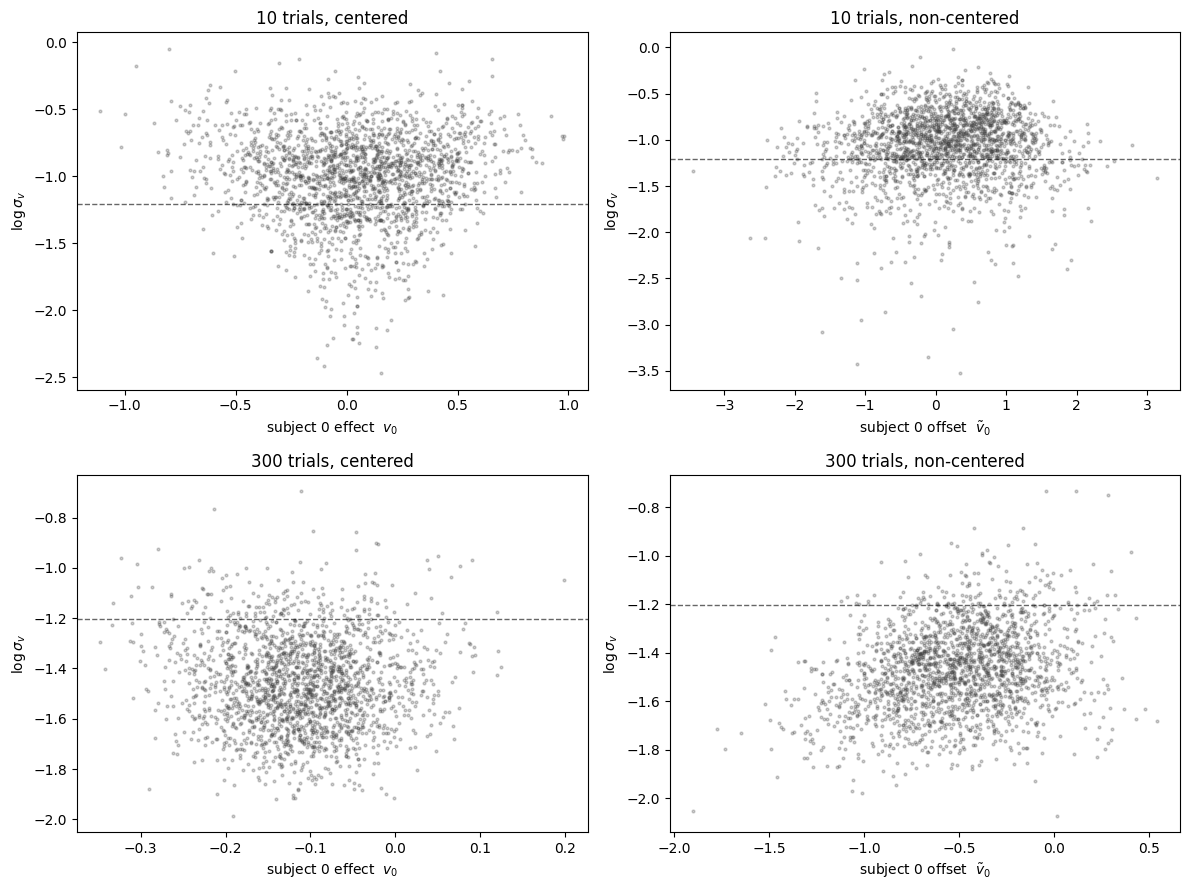

In [19]:
contrasts = [(10, "centered"), (10, "non-centered"), (300, "centered"), (300, "non-centered")]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (n_trials, label) in zip(axes.flat, contrasts):
    idata = idata_store[(n_trials, label)]

    sigma = idata.posterior[sigma_v_var].values.flatten()
    log_sigma = np.log(sigma)

    re_name = "v_1|participant_id_offset" if label == "non-centered" else "v_1|participant_id"
    subj_effect = idata.posterior[re_name].values[..., 0].flatten()

    ax.scatter(subj_effect, log_sigma, s=4, alpha=0.25, color="#404040")
    ax.axhline(np.log(sigma_v), color="k", ls="--", lw=1, alpha=0.6)

    xlabel = r"subject 0 offset  $\tilde v_0$" if label == "non-centered" else r"subject 0 effect  $v_0$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$\log \sigma_v$")
    ax.set_title(f"{n_trials} trials, {label}")
plt.tight_layout()
plt.show()

**Top-left** narrows toward small `σ_v` — the funnel. **Bottom-right** widens at small `σ_v` — the inverse funnel. 

### 6.2 Trace plots of `σ_v`

Each chain's `σ_v` values across 1000 samples. The dashed line is the true `σ_v = 0.3`.

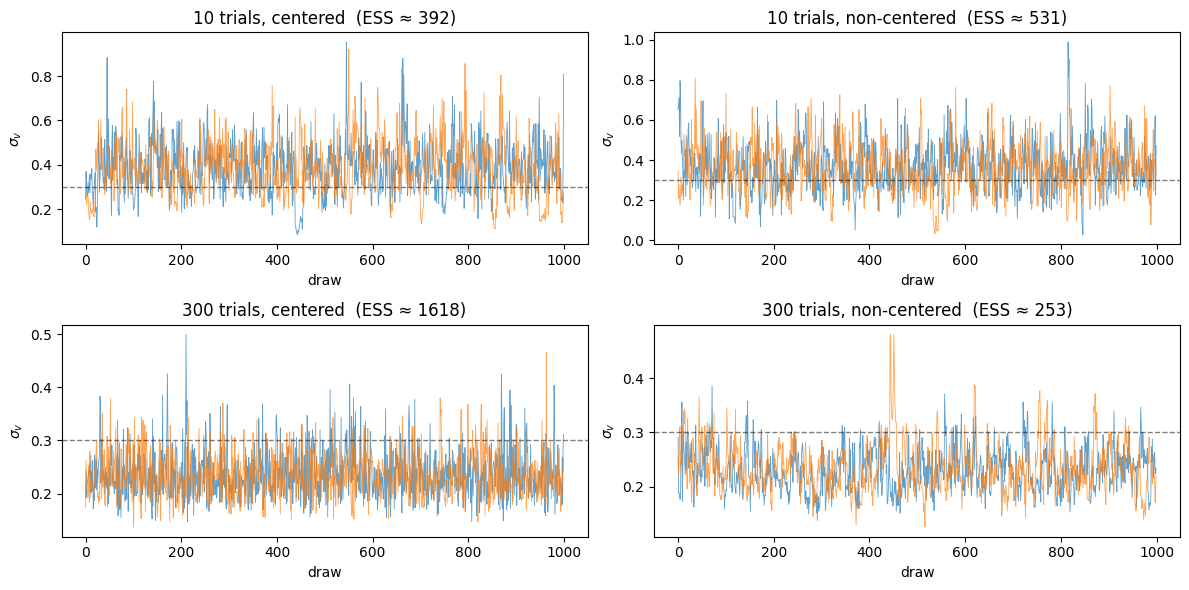

In [ ]:
ess_map = {(r.n_trials, r.parameterization): r.ess_sigma_v for r in results.itertuples()}

contrasts = [(10, "centered"), (10, "non-centered"), (300, "centered"), (300, "non-centered")]
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, (n_trials, label) in zip(axes.flat, contrasts):
    idata = idata_store[(n_trials, label)]
    samples = idata.posterior[sigma_v_var].values  
    for c in range(samples.shape[0]):
        ax.plot(samples[c], alpha=0.7, lw=0.6)
    ax.axhline(sigma_v, color="k", ls="--", lw=1, alpha=0.5)
    ax.set_title(f"{n_trials} trials, {label}  (ESS ≈ {ess_map[(n_trials, label)]:.0f})")
    ax.set_xlabel("draw")
    ax.set_ylabel(r"$\sigma_v$")
plt.tight_layout()
plt.show()

At 300 trials, centered (bottom-left) stays in a narrow band, while non-centered (bottom-right) swings wider and has a larger jump—matching its much lower ESS. At 10 trials the two look almost the same; the funnel is too mild at `σ_v = 0.3` to show up in the traces, so the difference only appears in the ESS numbers.

### 6.3 Recovery of `σ_v`

Estimated `σ_v` (mean ± sd) for both forms. Dashed line is the true `σ_v = 0.3`; dotted line is the actual spread of the 20 simulated subjects (≈ 0.222).

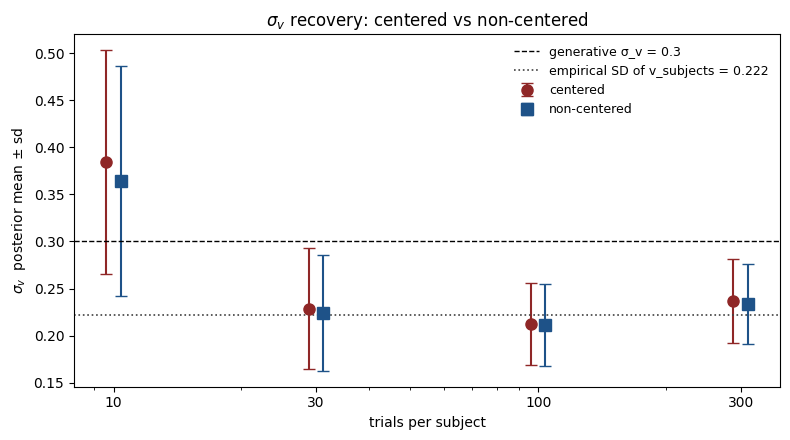

,n_trials,parameterization,post_mean,post_sd
0,10,centered,0.384,0.119
1,10,non-centered,0.364,0.123
2,30,centered,0.229,0.064
3,30,non-centered,0.224,0.061
4,100,centered,0.212,0.044
5,100,non-centered,0.211,0.044
6,300,centered,0.237,0.045
7,300,non-centered,0.233,0.043


In [18]:
rec_sigma = []
for n_trials in trial_conditions:
    for label in ["centered", "non-centered"]:
        idata = idata_store[(n_trials, label)]
        post = idata.posterior[sigma_v_var].values.flatten()
        rec_sigma.append({
            "n_trials": n_trials,
            "parameterization": label,
            "post_mean": float(np.mean(post)),
            "post_sd": float(np.std(post)),
        })
sigma_recovery = pd.DataFrame(rec_sigma)

empirical_sd = float(np.std(v_subjects, ddof=1))

fig, ax = plt.subplots(figsize=(8, 4.5))
for label, color, marker, off in [("centered", "#8F2727", "o", -0.04), ("non-centered", "#1E5288", "s", 0.04)]:
    sub = sigma_recovery[sigma_recovery.parameterization == label]
    x = sub.n_trials * (1 + off)
    ax.errorbar(x, sub.post_mean, yerr=sub.post_sd, fmt=marker,
                color=color, label=label, capsize=4, ms=8)
ax.axhline(sigma_v, color="k", ls="--", lw=1, label=f"generative σ_v = {sigma_v}")
ax.axhline(empirical_sd, color="#404040", ls=":", lw=1.2,
           label=f"empirical SD of v_subjects = {empirical_sd:.3f}")
ax.set_xscale("log")
ax.set_xticks(trial_conditions)
ax.set_xticklabels(trial_conditions)
ax.set_xlabel("trials per subject")
ax.set_ylabel(r"$\sigma_v$  posterior mean ± sd")
ax.set_title(r"$\sigma_v$ recovery: centered vs non-centered")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
sigma_recovery.round(3)

From 30 trials onward the two forms give the same answer—choosing centered vs non-centered changes how fast the sampler mixes (the ESS gap in §5), not the estimate itself. Both settle near the dotted line (0.222) rather than the dashed line (0.3), because we only drew 20 subjects and their actual spread differs from the value they were sampled from. At 10 trials the data is too thin to pin down `σ_v`, so the prior pulls both estimates up; centered is pulled slightly more, because the funnel makes the small-`σ_v` region harder to visit.